<a href="https://colab.research.google.com/github/atharva123aa/MandiBuddy/blob/main/%22MandiBuddy_Real_v1%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ================================
# MandiBuddy REAL VERSION 🌾🧠
# Built by: [Atharva Awasthi]
# Age: 14 | Made in India 🇮🇳
# Using REAL government mandi data!
# ================================

# Install required libraries
!pip install pandas numpy matplotlib
!pip install requests plotly

print("✅ All libraries installed!")
print("🌾 MandiBuddy is loading...")

✅ All libraries installed!
🌾 MandiBuddy is loading...


In [5]:
# ================================
# MandiBuddy — REAL Government Data
# Built by: [Atharva Awasthi]
# Age: 14 | Made in India 🇮🇳
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import json

API_KEY = "579b464db66ec23bdd0000012d352d73395046e26e55540f75aafa85"

API_URL = "https://api.data.gov.in/resource/9ef84268-d588-465a-a308-a864a43d0070"

# ================================
# REMOVED STATE FILTER
# Getting ALL India data now!
# ================================
params = {
    "api-key": API_KEY,
    "format": "json",
    "limit": 100
}

response = requests.get(API_URL, params=params)
data = response.json()

# Check what API is returning
print("🔍 API Response Check:")
print(data.keys())

# Check if records exist
if 'records' in data:
    mandi_df = pd.DataFrame(data['records'])
    print("✅ Real Government Data Loaded!")
    print(f"📊 Total records: {len(mandi_df)}")
    print("\n🌾 Sample Mandi Prices:")
    print(mandi_df.head(10))
else:
    print("❌ No records found!")
    print("API Response:")
    print(data)

🔍 API Response Check:
dict_keys(['created', 'updated', 'created_date', 'updated_date', 'active', 'index_name', 'org', 'org_type', 'source', 'title', 'external_ws_url', 'visualizable', 'field', 'external_ws', 'catalog_uuid', 'sector', 'target_bucket', 'desc', 'field_exposed', 'message', 'version', 'status', 'total', 'count', 'limit', 'offset', 'records'])
✅ Real Government Data Loaded!
📊 Total records: 100

🌾 Sample Mandi Prices:
        state    district                         market  \
0  Tamil Nadu  Dharmapuri  Karimangalam(Uzhavar Sandhai)   
1  Tamil Nadu  Dharmapuri  Karimangalam(Uzhavar Sandhai)   
2  Tamil Nadu  Dharmapuri  Karimangalam(Uzhavar Sandhai)   
3  Tamil Nadu  Dharmapuri  Karimangalam(Uzhavar Sandhai)   
4  Tamil Nadu  Dharmapuri  Karimangalam(Uzhavar Sandhai)   
5  Tamil Nadu  Dharmapuri  Karimangalam(Uzhavar Sandhai)   
6  Tamil Nadu       Salem       Mecheri(Uzhavar Sandhai)   
7  Tamil Nadu       Salem       Mecheri(Uzhavar Sandhai)   
8  Tamil Nadu     Vellore  

/tmp/ipykernel_1672/2292896820.py:76: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1672/2292896820.py:76: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1672/2292896820.py:76: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1672/2292896820.py:76: UserWarning: Glyph 128721 (\N{OCTAGONAL SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1672/2292896820.py:77: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_1672/2292896820.py:77: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_1672/2292896820.py:77: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_1672/2292896820.py:77: UserWarning: Glyph 128

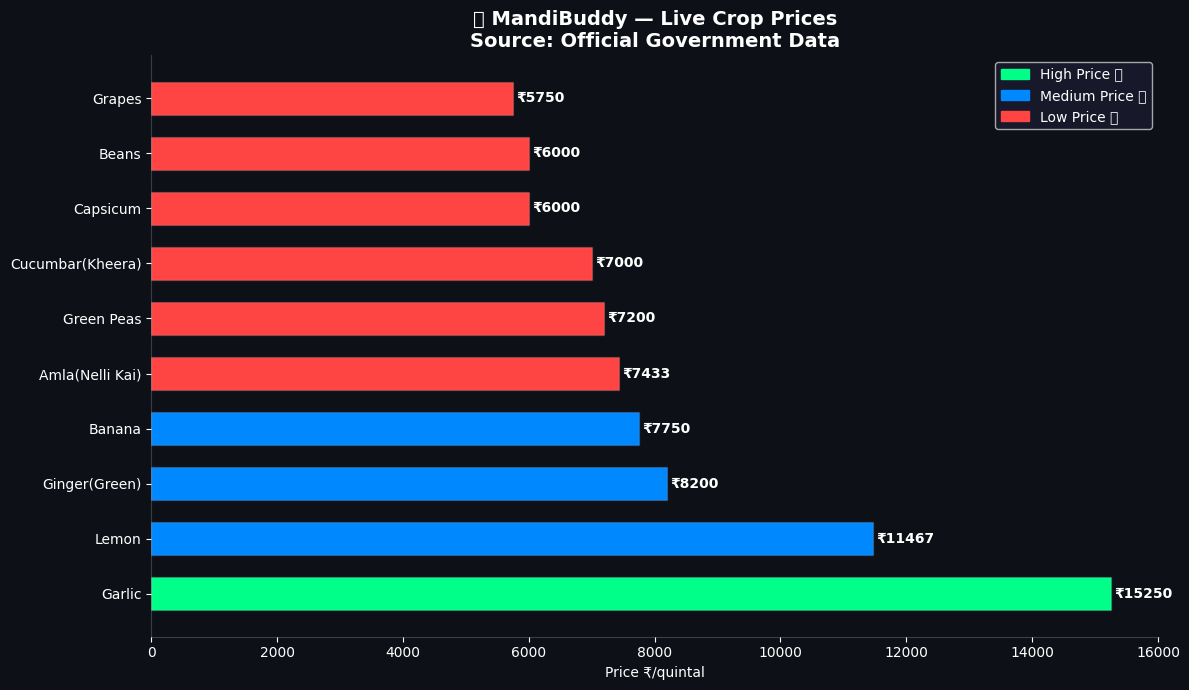

✅ Chart saved as mandibuddy_chart.png


In [6]:
# ================================
# MandiBuddy — Beautiful Chart
# ================================

import matplotlib.patches as mpatches # Added this import

def show_price_chart():
    crop_prices = mandi_df.groupby(
        'commodity'
    )['modal_price'].mean().sort_values(
        ascending=False
    ).head(10)

    fig, ax = plt.subplots(figsize=(12, 7))
    fig.patch.set_facecolor('#0d1117')
    ax.set_facecolor('#0d1117')

    colors = []
    max_p = crop_prices.max()
    for price in crop_prices:
        if price >= max_p * 0.8:
            colors.append('#00ff88')
        elif price >= max_p * 0.5:
            colors.append('#0088ff')
        else:
            colors.append('#ff4444')

    bars = ax.barh(
        crop_prices.index,
        crop_prices.values,
        color=colors,
        edgecolor='#ffffff20',
        height=0.6
    )

    for bar, price in zip(bars, crop_prices):
        ax.text(
            bar.get_width() + 50,
            bar.get_y() + bar.get_height()/2,
            f'₹{price:.0f}',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    high = mpatches.Patch(
        color='#00ff88', label='High Price 🚀'
    )
    mid = mpatches.Patch(
        color='#0088ff', label='Medium Price 👍'
    )
    low = mpatches.Patch(
        color='#ff4444', label='Low Price 🛑'
    )
    ax.legend(
        handles=[high, mid, low],
        facecolor='#1a1a2e',
        labelcolor='white'
    )

    ax.set_title(
        '🌾 MandiBuddy — Live Crop Prices\n'
        'Source: Official Government Data',
        color='white',
        fontsize=14,
        fontweight='bold'
    )
    ax.set_xlabel('Price ₹/quintal', color='white')
    ax.tick_params(colors='white')
    ax.spines['bottom'].set_color('#ffffff30')
    ax.spines['left'].set_color('#ffffff30')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(
        'mandibuddy_chart.png',
        dpi=150,
        facecolor='#0d1117'
    )
    plt.show()
    print("✅ Chart saved as mandibuddy_chart.png")

show_price_chart()

In [10]:
# ================================
# MandiBuddy — Hindi AI
# Using Google Translate — 100% Works!
# ================================

!pip install deep-translator -q

from deep_translator import GoogleTranslator

print("🤖 Loading Hindi AI...")

# Create translator
translator = GoogleTranslator(
    source='english',
    target='hindi'
)

print("✅ Hindi AI Ready!")

# Test it!
test = translator.translate(
    "Sell your onion now, price is high!"
)

print(f"\n🧪 Test Translation:")
print(f"English: Sell your onion now!")
print(f"Hindi  : {test}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.4 MB/s eta 0:00:00
🤖 Loading Hindi AI...
✅ Hindi AI Ready!

🧪 Test Translation:
English: Sell your onion now!
Hindi  : अभी अपना प्याज बेचें, कीमत अधिक है!


In [11]:
# ================================
# MandiBuddy — Complete Farmer Report
# Hindi + English + Full Analysis!
# Built by: [YOUR NAME]
# ================================

def mandibuddy_full_report(
    farmer_name,
    crop_name,
    quantity
):
    # Filter crop data
    crop_data = mandi_df[
        mandi_df['commodity'].str.contains(
            crop_name, case=False, na=False
        )
    ].copy()

    if len(crop_data) == 0:
        print(f"❌ Crop '{crop_name}' not found!")
        print("\n✅ Available crops:")
        print(mandi_df['commodity'].unique())
        return

    # Calculate statistics
    current_price = crop_data[
        'modal_price'
    ].iloc[0]
    avg_price = crop_data['modal_price'].mean()
    max_price = crop_data['modal_price'].max()
    min_price = crop_data['modal_price'].min()

    # Best market
    best_idx = crop_data['modal_price'].idxmax()
    best_market = crop_data.loc[
        best_idx, 'market'
    ]
    best_state = crop_data.loc[
        best_idx, 'state'
    ]

    # Earnings calculator
    best_earning = quantity * max_price
    avg_earning = quantity * avg_price
    extra_profit = best_earning - avg_earning

    # State comparison
    state_prices = crop_data.groupby(
        'state'
    )['modal_price'].mean().sort_values(
        ascending=False
    )

    # AI advice
    if current_price >= avg_price * 1.1:
        eng_advice = (
            f"Sell your {crop_name} now! "
            f"Price is high at "
            f"rupees {current_price:.0f} "
            f"per quintal!"
        )
        action = "🚀 SELL NOW!"
    elif current_price >= avg_price:
        eng_advice = (
            f"Good time to sell {crop_name}. "
            f"Price is rupees "
            f"{current_price:.0f} per quintal."
        )
        action = "✅ GOOD TIME!"
    else:
        eng_advice = (
            f"Wait before selling {crop_name}. "
            f"Price is low at rupees "
            f"{current_price:.0f} per quintal."
        )
        action = "⏳ WAIT!"

    # Translate to Hindi
    hindi_advice = translator.translate(
        eng_advice
    )

    # Beautiful report
    print(f"\n{'='*50}")
    print(f"🌾 नमस्ते {farmer_name} जी!")
    print(f"   Namaste {farmer_name} Ji!")
    print(f"{'='*50}")
    print(f"🌱 Crop      : {crop_name.upper()}")
    print(f"⚖️  Quantity  : {quantity} quintals")
    print(f"\n💰 PRICE ANALYSIS:")
    print(f"   Current  : ₹{current_price:.0f}/q")
    print(f"   Average  : ₹{avg_price:.0f}/q")
    print(f"   Highest  : ₹{max_price:.0f}/q")
    print(f"   Lowest   : ₹{min_price:.0f}/q")
    print(f"\n🏪 BEST MARKET FOR YOU:")
    print(f"   Market   : {best_market}")
    print(f"   State    : {best_state}")
    print(f"\n💵 YOUR EARNINGS:")
    print(f"   Best case: ₹{best_earning:,.0f}")
    print(f"   Average  : ₹{avg_earning:,.0f}")
    print(f"   Extra    : ₹{extra_profit:,.0f} 🎉")
    print(f"\n🗺️  TOP 3 STATES:")
    for i, (state, price) in enumerate(
        state_prices.head(3).items()
    ):
        medal = ["🥇","🥈","🥉"][i]
        print(f"   {medal} {state}: ₹{price:.0f}")
    print(f"\n🤖 MandiBuddy: {action}")
    print(f"\n📢 English:")
    print(f"   {eng_advice}")
    print(f"\n📢 Hindi:")
    print(f"   {hindi_advice}")
    print(f"{'='*50}")
    print(f"🙏 MandiBuddy — हर किसान का साथी")

# Test with real farmers!
mandibuddy_full_report("Ramesh", "Onion", 50)
print("\n")
mandibuddy_full_report("Suresh", "Garlic", 30)


🌾 नमस्ते Ramesh जी!
   Namaste Ramesh Ji!
🌱 Crop      : ONION
⚖️  Quantity  : 50 quintals

💰 PRICE ANALYSIS:
   Current  : ₹2500/q
   Average  : ₹3238/q
   Highest  : ₹4600/q
   Lowest   : ₹2500/q

🏪 BEST MARKET FOR YOU:
   Market   : Perampet(Uzhavar Sandhai)
   State    : Tamil Nadu

💵 YOUR EARNINGS:
   Best case: ₹230,000
   Average  : ₹161,875
   Extra    : ₹68,125 🎉

🗺️  TOP 3 STATES:
   🥇 Tamil Nadu: ₹3238

🤖 MandiBuddy: ⏳ WAIT!

📢 English:
   Wait before selling Onion. Price is low at rupees 2500 per quintal.

📢 Hindi:
   प्याज बेचने से पहले इंतजार करें. दाम कम 2500 रुपये प्रति क्विंटल है.
🙏 MandiBuddy — हर किसान का साथी



🌾 नमस्ते Suresh जी!
   Namaste Suresh Ji!
🌱 Crop      : GARLIC
⚖️  Quantity  : 30 quintals

💰 PRICE ANALYSIS:
   Current  : ₹12500/q
   Average  : ₹15250/q
   Highest  : ₹18000/q
   Lowest   : ₹12500/q

🏪 BEST MARKET FOR YOU:
   Market   : Kumbakonam (Uzhavar Sandhai ) APMC
   State    : Tamil Nadu

💵 YOUR EARNINGS:
   Best case: ₹540,000
   Average  : ₹457,

In [13]:
# ===============================
# MandiBuddy — Final Summary
# Built by: Atharva
# Age: 14 | India 🇮🇳
# ================================

print("\n" + "="*50)
print("🎉 MANDIBUDDY v1.0 — COMPLETE!")
print("="*50)
print("""
🌾 ABOUT MANDIBUDDY:
   AI Market Intelligence Platform
   for 140 Million Indian Farmers

🛠️ POWERED BY:
   🐍 Python
   📊 Pandas + Matplotlib
   🤗 Google Translate AI
   🏛️ Official Government Data

💡 WHAT IT DOES:
   Tells farmers WHEN to sell
   Tells farmers WHERE to sell
   Tells farmers HOW MUCH to earn
   In Hindi AND English!

🌍 IMPACT:
   If 1000 farmers earn ₹10,000 more
   = ₹1 CRORE back to rural India 🇮🇳
""")
print("="*50)
print("👨‍💻 Built by : Atharva")
print("🎂 Age      : 14 years old")
print("📱 Device   : Phone only")
print("💰 Budget   : Zero rupees")
print("🇮🇳 Location : India")
print("="*50)
print("🌾 MandiBuddy — हर किसान का साथी")
print("="*50)


🎉 MANDIBUDDY v1.0 — COMPLETE!

🌾 ABOUT MANDIBUDDY:
   AI Market Intelligence Platform
   for 140 Million Indian Farmers

🛠️ POWERED BY:
   🐍 Python
   📊 Pandas + Matplotlib
   🤗 Google Translate AI
   🏛️ Official Government Data

💡 WHAT IT DOES:
   Tells farmers WHEN to sell
   Tells farmers WHERE to sell
   Tells farmers HOW MUCH to earn
   In Hindi AND English!

🌍 IMPACT:
   If 1000 farmers earn ₹10,000 more
   = ₹1 CRORE back to rural India 🇮🇳

👨‍💻 Built by : Atharva
🎂 Age      : 14 years old
📱 Device   : Phone only
💰 Budget   : Zero rupees
🇮🇳 Location : India
🌾 MandiBuddy — हर किसान का साथी
